computer vision is the field of study enabling computers to understand , visualise and analyse the world through imaes and videos like humans.

In [3]:
%pip install opencv-python
%pip install matplotlib

In [4]:
import cv2
import matplotlib.pyplot as plt


In [5]:
# task 1

class GroceryManager:

    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        if quantity <= 0:
            print("error: quantity must be greater than 0.")
            return

        if price < 0:
            print("error: price cannot be negative.")
            return

        if item in self.items:
            self.items[item][0] += quantity
        else:
            self.items[item] = [quantity, price]

        print(f"{item} added successfully.")

    def remove_item(self, item):
        if item not in self.items:
            print(f"error: {item} does not exist in the grocery list.")
            return

        del self.items[item]
        print(f"{item} removed successfully.")

    def view_list(self):
        if not self.items:
            print(" grocery list is empty.")
            return

        print("\ngrocery list:\n")

        for item, details in self.items.items():
            quantity = details[0]
            price = details[1]

            print(f"{item}: quantity = {quantity}, price = ${price:.2f}")

        print("-" * 40)

    def calculate_total(self):
        total = 0

        for item, details in self.items.items():
            quantity = details[0]
            price = details[1]

            total += quantity * price

        return total


# Example usage
grocery = GroceryManager()

grocery.add_item("Milk", 2, 3.50)
grocery.add_item("Bread", 1, 2.00)
grocery.add_item("Eggs", 12, 0.25)

grocery.view_list()

total = grocery.calculate_total()
print(f"\ntotsl cost: ${total:.2f}")

grocery.remove_item("Bread")
grocery.view_list()

# Trying to remove an item that doesn't exist
grocery.remove_item("butter")



Milk added successfully.
Bread added successfully.
Eggs added successfully.

grocery list:

Milk: quantity = 2, price = $3.50
Bread: quantity = 1, price = $2.00
Eggs: quantity = 12, price = $0.25
----------------------------------------

totsl cost: $12.00
Bread removed successfully.

grocery list:

Milk: quantity = 2, price = $3.50
Eggs: quantity = 12, price = $0.25
----------------------------------------
error: butter does not exist in the grocery list.


In [6]:
# task 2


students = {
    "001": {
        "Name": "amna",
        "Major": "Artificial Intelligence",
        "Grades": [85, 90, 88, 92]
    },

    "002": {
        "Name": "sara",
        "Major": "Computer Science",
        "Grades": [78, 85, 80, 82]
    },

    "003": {
        "Name": "ahmed",
        "Major": "Artificial Intelligence",
        "Grades": [95, 91, 94, 97]
    },

    "004": {
        "Name": "arham",
        "Major": "Data Science",
        "Grades": [88, 86, 90, 89]
    }
}


def highest_average_student(students):

    highest_average = 0
    highest_student = ""

    for student_id, student_info in students.items():

        grades = student_info["Grades"]
        average = sum(grades) / len(grades)

        if average > highest_average:
            highest_average = average
            highest_student = student_info["Name"]

    return highest_student


def search_by_major(students, major):

    print(f"\nStudents enrolled in {major}:")

    found = False

    for student_id, student_info in students.items():

        if student_info["Major"].lower() == major.lower():
            print(f"ID: {student_id}, Name: {student_info['Name']}")
            found = True

    if not found:
        print("No students found in this major.")


top_student = highest_average_student(students)

print("Student with the highest average grade:", top_student)


search_by_major(students, "Artificial Intelligence")


Student with the highest average grade: ahmed

Students enrolled in Artificial Intelligence:
ID: 001, Name: amna
ID: 003, Name: ahmed


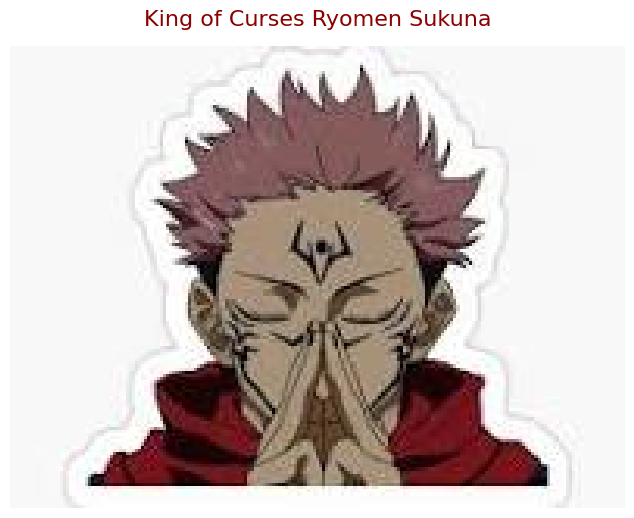

In [8]:
# task 3

import cv2
import matplotlib.pyplot as plt

# Path to the image
image_path = "/content/sukuna"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))

    plt.imshow(image_rgb)

    plt.axis("off")

    plt.title(
        "King of Curses Ryomen Sukuna",
        fontsize=16,
        color="darkred",
        pad=15
    )

    plt.show()



Canvas center coordinates: (400, 400)


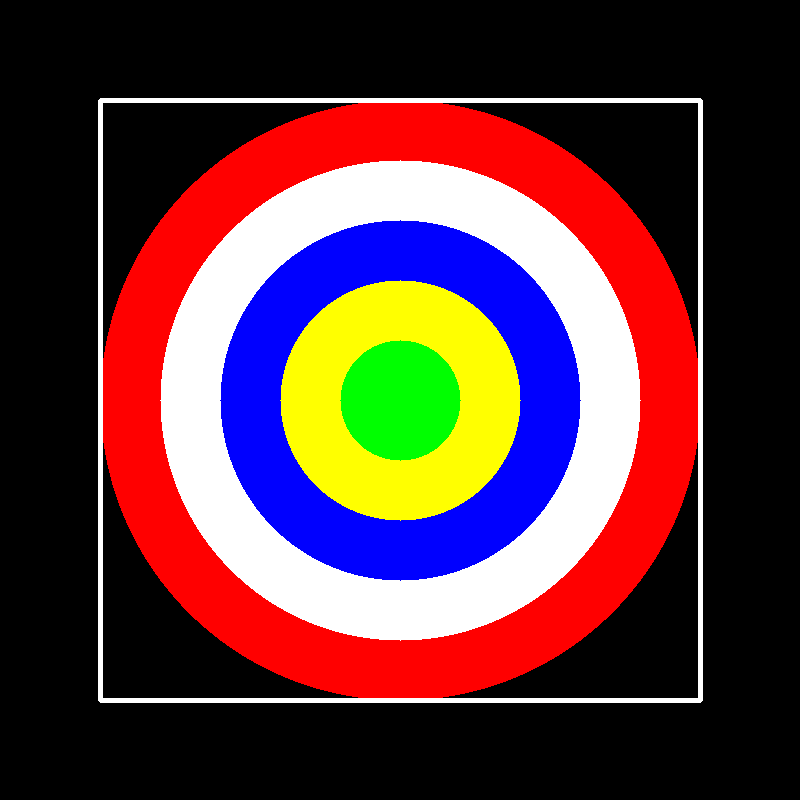

In [10]:
# task 4

import numpy as np
import cv2
from google.colab.patches import cv2_imshow

canvas = np.zeros((800, 800, 3), dtype=np.uint8)

center_x = 800 // 2
center_y = 800 // 2
center = (center_x, center_y)

print("Canvas center coordinates:", center)

red = (0, 0, 255)
white = (255, 255, 255)
blue = (255, 0, 0)
yellow = (0, 255, 255)
green = (0, 255, 0)

cv2.circle(canvas, center, 300, red, -1)
cv2.circle(canvas, center, 240, white, -1)
cv2.circle(canvas, center, 180, blue, -1)
cv2.circle(canvas, center, 120, yellow, -1)
cv2.circle(canvas, center, 60, green, -1)

top_left = (center_x - 300, center_y - 300)
bottom_right = (center_x + 300, center_y + 300)

cv2.rectangle(canvas, top_left, bottom_right, white, 3)

cv2_imshow(canvas)


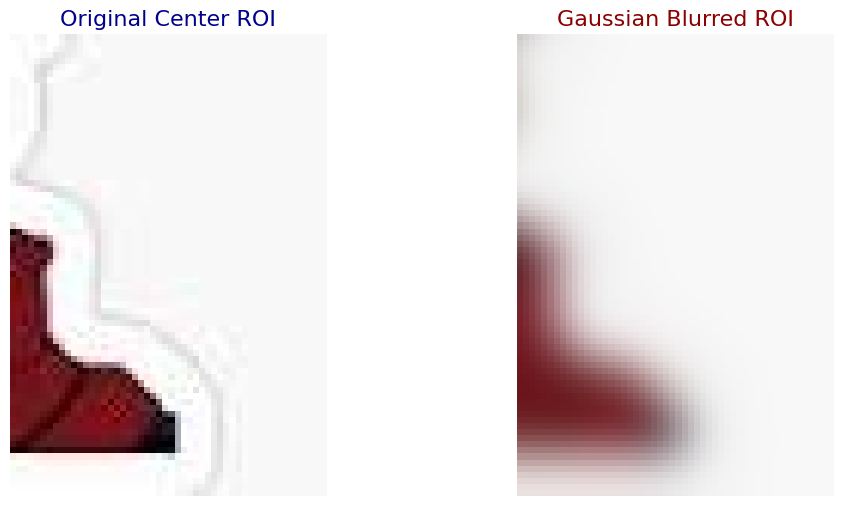

In [11]:
# task 5

import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/sukuna"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blurred_image = cv2.GaussianBlur(image_rgb, (25, 25), 0)

    # image dimensions
    height, width = image_rgb.shape[:2]

    #exact center
    center_x = width // 2
    center_y = height // 2

    # ROI size
    roi_size = 300
    half = roi_size // 2

    original_roi = image_rgb[
        center_y - half:center_y + half,
        center_x - half:center_x + half
    ]

    blurred_roi = blurred_image[
        center_y - half:center_y + half,
        center_x - half:center_x + half
    ]

    # Display the two ROIs side-by-side
    plt.figure(figsize=(12, 6))

    # Original ROI
    plt.subplot(1, 2, 1)
    plt.imshow(original_roi)
    plt.axis("off")
    plt.title(
        "Original Center ROI",
        fontsize=16,
        color="darkblue"
    )

    # Blurred ROI
    plt.subplot(1, 2, 2)
    plt.imshow(blurred_roi)
    plt.axis("off")
    plt.title(
        "Gaussian Blurred ROI",
        fontsize=16,
        color="darkred"
    )

    plt.show()


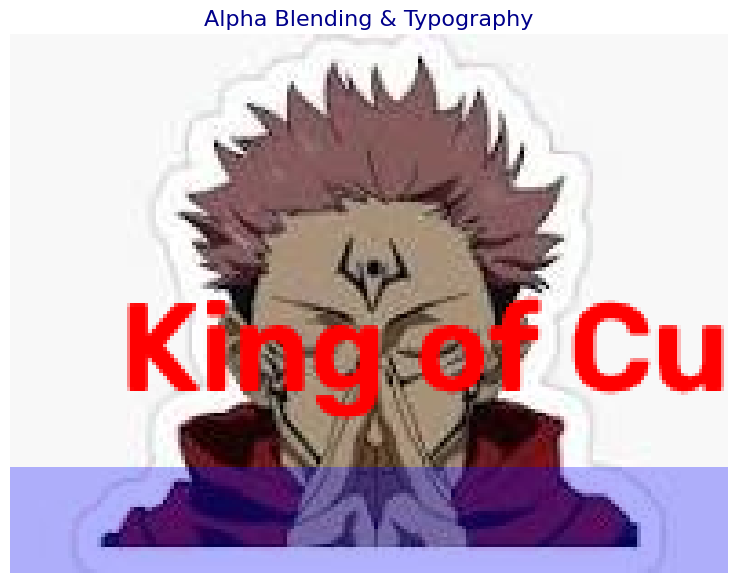

In [13]:
#task 6
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/sukuna"


image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")

else:
    height, width = image.shape[:2]

    overlay_height = int(height * 0.20)

    overlay = image.copy()

    cv2.rectangle(
        overlay,
        (0, height - overlay_height),
        (width, height),
        (255, 0, 0),   # Blue in BGR
        -1
    )


    blended = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

    title = "King of Curses"

    cv2.putText(
        blended,
        title,
        (30, height - 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0, 0, 255),
        3,
        cv2.LINE_AA
    )

    # Convert BGR to RGB for Matplotlib
    blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

    # Display the final image
    plt.figure(figsize=(10, 7))
    plt.imshow(blended_rgb)
    plt.axis("off")
    plt.title(
        "Alpha Blending & Typography",
        fontsize=16,
        color="darkblue"
    )
    plt.show()


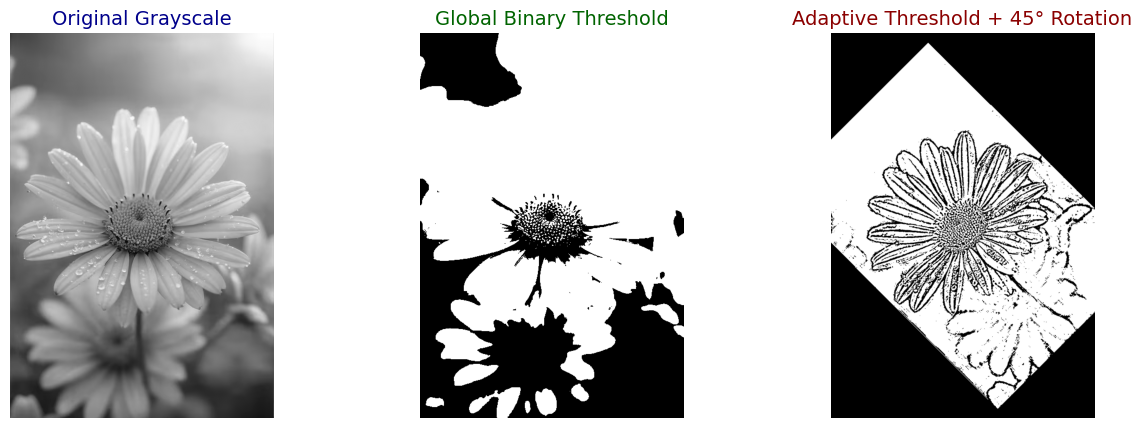

In [14]:
# task 7

import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/flower"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found.")

else:

    _, global_threshold = cv2.threshold(
        image,
        127,
        255,
        cv2.THRESH_BINARY
    )


    adaptive_threshold = cv2.adaptiveThreshold(
        image,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    height, width = adaptive_threshold.shape

    center = (width // 2, height // 2)

    rotation_matrix = cv2.getRotationMatrix2D(
        center,
        45,       # Rotate exactly 45 degrees
        0.8       # Scale by 0.8
    )

    rotated_adaptive = cv2.warpAffine(
        adaptive_threshold,
        rotation_matrix,
        (width, height)
    )


    plt.figure(figsize=(15, 5))

    # Original grayscale image
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(
        "Original Grayscale",
        fontsize=14,
        color="darkblue"
    )

    # Global Threshold
    plt.subplot(1, 3, 2)
    plt.imshow(global_threshold, cmap="gray")
    plt.axis("off")
    plt.title(
        "Global Binary Threshold",
        fontsize=14,
        color="darkgreen"
    )

    #  Threshold + Rotation
    plt.subplot(1, 3, 3)
    plt.imshow(rotated_adaptive, cmap="gray")
    plt.axis("off")
    plt.title(
        "Adaptive Threshold + 45° Rotation",
        fontsize=14,
        color="darkred"
    )

    plt.show()


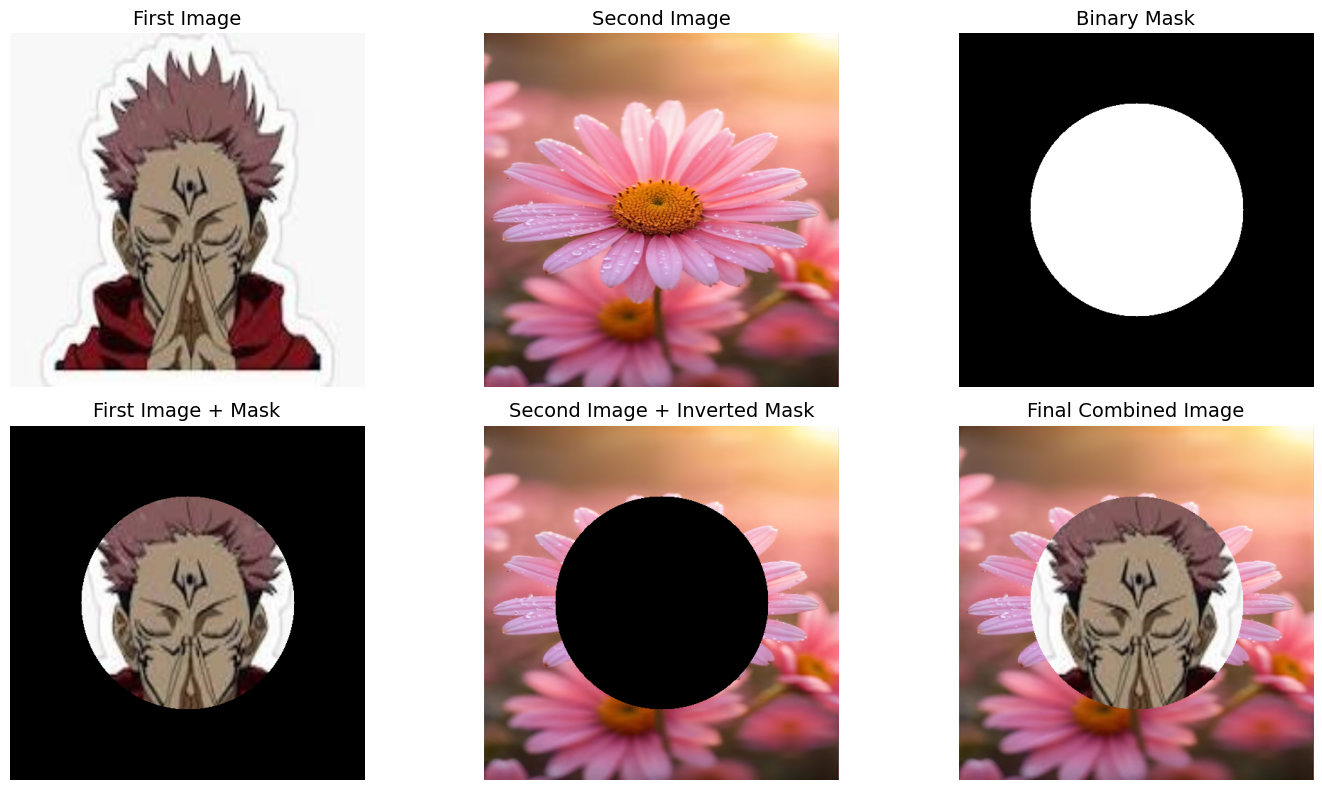

In [15]:
# task 8

import cv2
import numpy as np
import matplotlib.pyplot as plt

image1_path = "/content/sukuna"
image2_path = "/content/flower"

image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)

if image1 is None:
    print("Error: First image not found.")

elif image2 is None:
    print("Error: Second image not found.")

else:
    image1 = cv2.resize(image1, (500, 500))
    image2 = cv2.resize(image2, (500, 500))

    mask = np.zeros((500, 500), dtype=np.uint8)

    # thick white circle in the center
    cv2.circle(
        mask,
        (250, 250),   # Center
        150,          # Radius
        255,          # White
        -1            # Filled circle
    )

    foreground = cv2.bitwise_and(
        image1,
        image1,
        mask=mask
    )

    inverted_mask = cv2.bitwise_not(mask)


    background = cv2.bitwise_and(
        image2,
        image2,
        mask=inverted_mask
    )

    result = cv2.bitwise_or(
        foreground,
        background
    )

    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("First Image", fontsize=14)

    plt.subplot(2, 3, 2)
    plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Second Image", fontsize=14)

    # binary mask
    plt.subplot(2, 3, 3)
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.title("Binary Mask", fontsize=14)

    # fg first image
    plt.subplot(2, 3, 4)
    plt.imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("First Image + Mask", fontsize=14)

    # bg second image
    plt.subplot(2, 3, 5)
    plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Second Image + Inverted Mask", fontsize=14)

# final image combine
    plt.subplot(2, 3, 6)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Final Combined Image", fontsize=14)

    plt.tight_layout()
    plt.show()


In [16]:
# task 9

import cv2
import numpy as np
import pandas as pd

image_path = "/content/flower"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")

else:
    #converting BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    red = image_rgb[:, :, 0].flatten()
    green = image_rgb[:, :, 1].flatten()
    blue = image_rgb[:, :, 2].flatten()

    df = pd.DataFrame({
        "Red": red,
        "Green": green,
        "Blue": blue
    })

    print("Pixel Data:")
    print(df.head())

    summary = df.describe()

    print("\nStatistical Summary:")
    print(summary)


Pixel Data:
   Red  Green  Blue
0   87     54    37
1   88     55    38
2   89     56    39
3   91     58    41
4   93     60    43

Statistical Summary:
                 Red          Green           Blue
count  374440.000000  374440.000000  374440.000000
mean      195.068839     124.426666     123.767990
std        52.490908      47.458963      55.610357
min        21.000000       0.000000       0.000000
25%       164.000000      87.000000      82.000000
50%       209.000000     125.000000     128.000000
75%       240.000000     158.000000     164.000000
max       255.000000     255.000000     255.000000
